# Remnant Displacement and Return Times

In [1]:
import warnings
warnings.filterwarnings('ignore', 'Wswiglal-redir-stdio')

import numpy as np
import matplotlib.pyplot as plt
from gwGenealogy.utils import set_rcparams
from gwGenealogy.hosts import (
    PlummerCluster,
    plummer_apocentre,
    dynamical_friction_time,
)
from gwGenealogy.binaries import BBHs, BBHRemnant, sample_masses, sample_spins

set_rcparams()

lal.MSUN_SI != Msun


## Generate a realistic kick distribution

We sample a population of 1G+1G BBH mergers and compute kicks using `BBHRemnant`.

In [2]:
N = 5000

m1, m2 = sample_masses(N, m_min=5, m_max=50, m1_distribution='powerlaw', alpha=-2.35, seed=42)
chi1, chi2 = sample_spins(N, chi_max=0.5, spin_magnitude='uniform', spin_angles='isotropic', seed=43)

bbh = BBHs(
    m1=m1, m2=m2,
    a1=np.linalg.norm(chi1, axis=1),
    a2=np.linalg.norm(chi2, axis=1),
    theta1=np.arccos(chi1[:, 2] / np.linalg.norm(chi1, axis=1)),
    theta2=np.arccos(chi2[:, 2] / np.linalg.norm(chi2, axis=1)),
)

rem = BBHRemnant(bbh=bbh, precessing=False, kick_model='hlz')

v_kick = rem.vkick
M_bh = rem.Mf

print(f"Kick range: {v_kick.min():.1f} - {v_kick.max():.1f} km/s")
print(f"Remnant mass range: {M_bh.min():.1f} - {M_bh.max():.1f} Msun")

Kick range: 0.3 - 285.2 km/s
Remnant mass range: 9.6 - 87.8 Msun


## Apocentre displacement (r_max)

For a bound remnant kicked with velocity $v_{\rm kick} < v_{\rm esc}$ in a Plummer potential, the radial-orbit apocentre is:

$$r_{\rm max} = a \sqrt{(1 - u^2)^{-2} - 1}, \quad u = v_{\rm kick}/v_{\rm esc}$$

Remnants kicked near the escape speed reach very large displacements and may exceed the tidal radius.

In [3]:
cluster_gc = PlummerCluster(Mcl=1e6, r_h=3.0, cluster_type='GC')
print(cluster_gc)

# Apocentre for bound kicks
bound = v_kick < cluster_gc.v_esc
v_bound = v_kick[bound]
r_max = plummer_apocentre(v_bound, cluster_gc.v_esc, cluster_gc.a)

print(f"\nBound fraction: {bound.mean():.3f}")
print(f"Apocentre range: {r_max.min():.2f} - {r_max.max():.1f} pc")
print(f"Tidal radius: {cluster_gc.r_t:.1f} pc")
print(f"Fraction within tidal radius: {(r_max <= cluster_gc.r_t).mean():.3f}")

PlummerCluster(Mcl=1.00e+06, r_h=3.00, a=2.30, v_esc=61.2 km/s, v_core=33.1 km/s, r_t=15.0 pc, type=GC)

Bound fraction: 0.237
Apocentre range: 0.02 - 1771.7 pc
Tidal radius: 15.0 pc
Fraction within tidal radius: 0.900


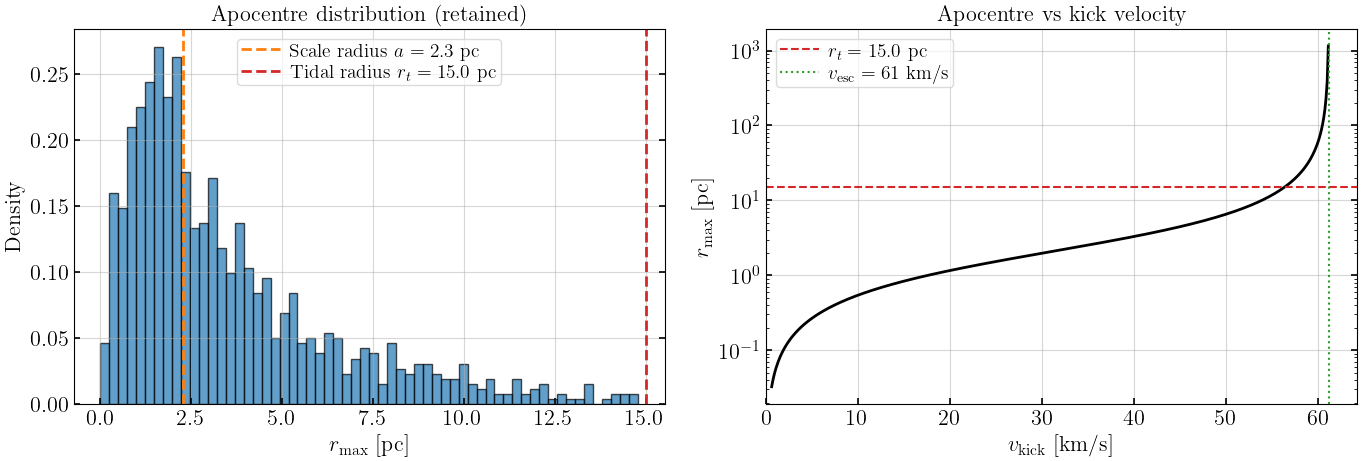

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: r_max distribution
retained = r_max[r_max <= cluster_gc.r_t]
axes[0].hist(retained, bins=60, density=True, edgecolor='black', alpha=0.7)
axes[0].axvline(cluster_gc.a, color='C1', ls='--', lw=2, label=f'Scale radius $a = {cluster_gc.a:.1f}$ pc')
axes[0].axvline(cluster_gc.r_t, color='C3', ls='--', lw=2, label=f'Tidal radius $r_t = {cluster_gc.r_t:.1f}$ pc')
axes[0].set_xlabel(r'$r_{\rm max}$ [pc]')
axes[0].set_ylabel('Density')
axes[0].set_title('Apocentre distribution (retained)')
axes[0].legend()

# Right: r_max vs v_kick
u = np.linspace(0.01, 0.999, 500)
r_curve = cluster_gc.a * np.sqrt((1.0 - u**2)**(-2) - 1.0)
axes[1].semilogy(u * cluster_gc.v_esc, r_curve, 'k-', lw=2)
axes[1].axhline(cluster_gc.r_t, color='C3', ls='--', lw=1.5, label=f'$r_t = {cluster_gc.r_t:.1f}$ pc')
axes[1].axvline(cluster_gc.v_esc, color='C2', ls=':', lw=1.5, label=f'$v_{{\\rm esc}} = {cluster_gc.v_esc:.0f}$ km/s')
axes[1].set_xlabel(r'$v_{\rm kick}$ [km/s]')
axes[1].set_ylabel(r'$r_{\rm max}$ [pc]')
axes[1].set_title('Apocentre vs kick velocity')
axes[1].set_xlim(0, cluster_gc.v_esc * 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

## Dynamical friction return time (t_DF)

A retained remnant sinks back to the cluster core via Chandrasekhar dynamical friction. The orbit-averaged return time depends on the kick velocity, cluster properties, and remnant mass.

In [5]:
cluster_gc.merger_analysis(v_kick, M_bh)

t_df_ret = cluster_gc.t_df[cluster_gc.retained]

print(f"P_ret  = {cluster_gc.P_ret:.3f}")
print(f"P_hier = {cluster_gc.P_hier:.4f}")
print(f"Return time range: {np.nanmin(t_df_ret):.2f} - {np.nanmax(t_df_ret):.1f} Myr")
print(f"Median return time: {np.nanmedian(t_df_ret):.1f} Myr")

P_ret  = 0.213
P_hier = 0.0111
Return time range: 21.28 - 21165.7 Myr
Median return time: 454.3 Myr


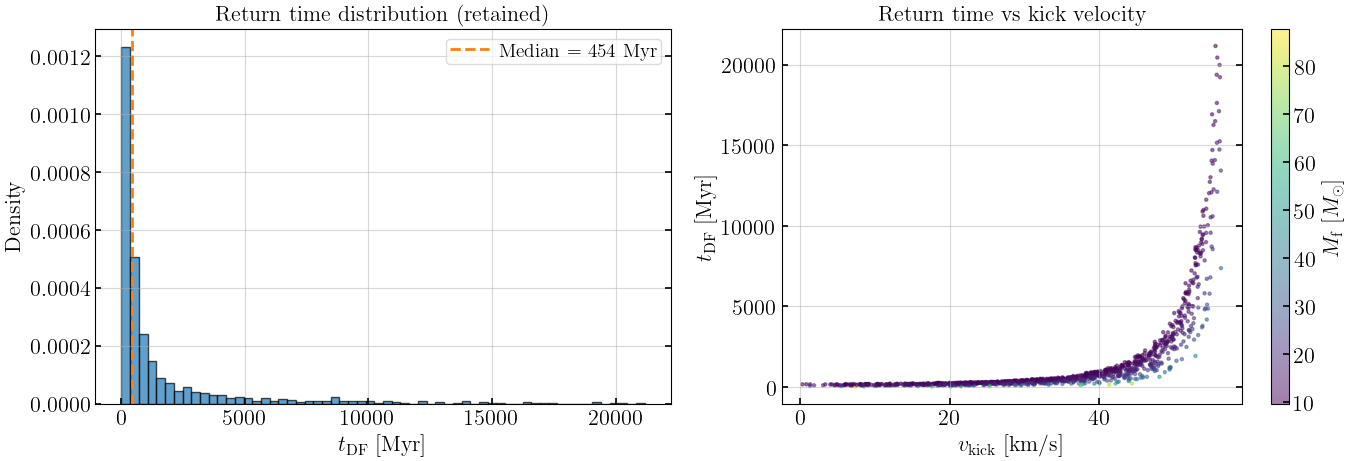

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: t_DF distribution
axes[0].hist(t_df_ret, bins=60, density=True, edgecolor='black', alpha=0.7)
axes[0].axvline(np.median(t_df_ret), color='C1', ls='--', lw=2, label=f'Median = {np.median(t_df_ret):.0f} Myr')
axes[0].set_xlabel(r'$t_{\rm DF}$ [Myr]')
axes[0].set_ylabel('Density')
axes[0].set_title('Return time distribution (retained)')
axes[0].legend()

# Right: t_DF vs v_kick
idx = cluster_gc.retained
sc = axes[1].scatter(v_kick[idx], cluster_gc.t_df[idx], c=M_bh[idx],
                     s=5, alpha=0.5, cmap='viridis', rasterized=True)
axes[1].set_xlabel(r'$v_{\rm kick}$ [km/s]')
axes[1].set_ylabel(r'$t_{\rm DF}$ [Myr]')
axes[1].set_title('Return time vs kick velocity')
cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label(r'$M_{\rm f}\;[M_\odot]$')

plt.tight_layout()
plt.show()

## Displacement and return time: joint view

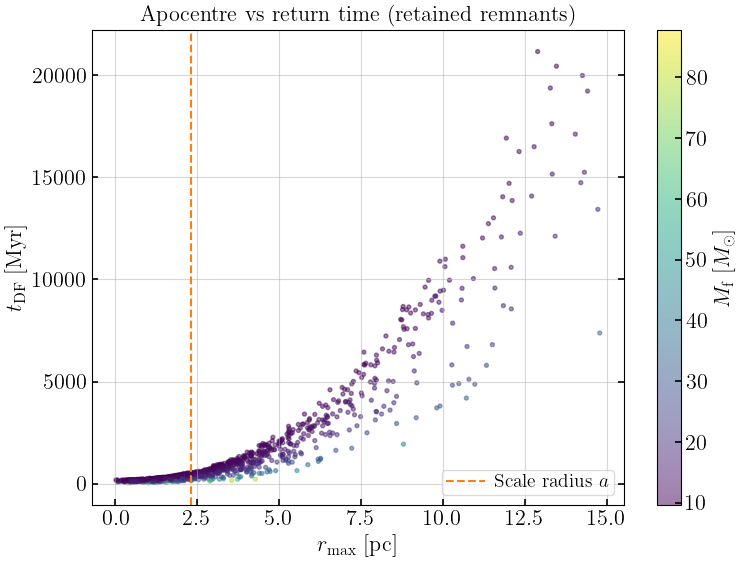

In [7]:
r_max_ret = cluster_gc.r_max[cluster_gc.retained]
t_df_ret = cluster_gc.t_df[cluster_gc.retained]
M_bh_ret = M_bh[cluster_gc.retained]

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(r_max_ret, t_df_ret, c=M_bh_ret, s=8, alpha=0.5,
                cmap='viridis', rasterized=True)
ax.axvline(cluster_gc.a, color='C1', ls='--', lw=1.5, label=f'Scale radius $a$')
ax.set_xlabel(r'$r_{\rm max}$ [pc]')
ax.set_ylabel(r'$t_{\rm DF}$ [Myr]')
ax.set_title('Apocentre vs return time (retained remnants)')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r'$M_{\rm f}\;[M_\odot]$')
ax.legend()
plt.tight_layout()
plt.show()

## Dependence on cluster mass

Compare displacement and return time distributions across different cluster masses.

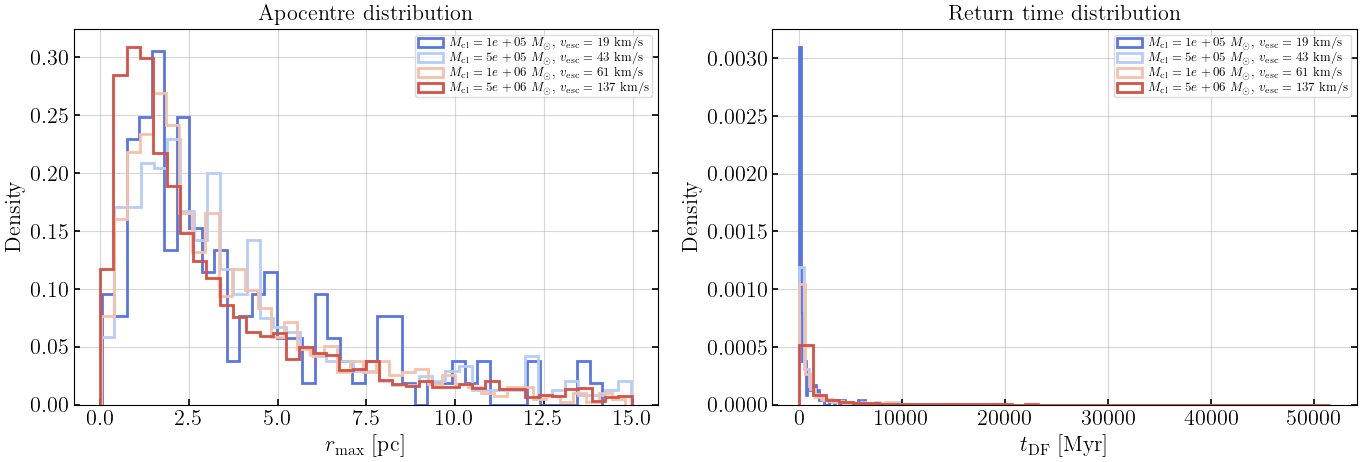

In [8]:
cluster_masses = [1e5, 5e5, 1e6, 5e6]
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(cluster_masses)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for Mcl, c in zip(cluster_masses, colors):
    cl = PlummerCluster(Mcl=Mcl, r_h=3.0, cluster_type='GC')
    cl.merger_analysis(v_kick, M_bh)
    
    if cl.retained.any():
        label = rf'$M_{{\rm cl}} = {Mcl:.0e}\;M_\odot$, $v_{{\rm esc}}={cl.v_esc:.0f}$ km/s'
        r_ret = cl.r_max[cl.retained]
        t_ret = cl.t_df[cl.retained]
        axes[0].hist(r_ret, bins=40, density=True, histtype='step', lw=2, color=c, label=label)
        axes[1].hist(t_ret, bins=40, density=True, histtype='step', lw=2, color=c, label=label)

axes[0].set_xlabel(r'$r_{\rm max}$ [pc]')
axes[0].set_ylabel('Density')
axes[0].set_title('Apocentre distribution')
axes[0].legend(fontsize=9)

axes[1].set_xlabel(r'$t_{\rm DF}$ [Myr]')
axes[1].set_ylabel('Density')
axes[1].set_title('Return time distribution')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## GC vs NSC

Nuclear star clusters (NSCs) are more massive and have higher escape speeds, leading to shorter return times and smaller displacements for retained remnants.

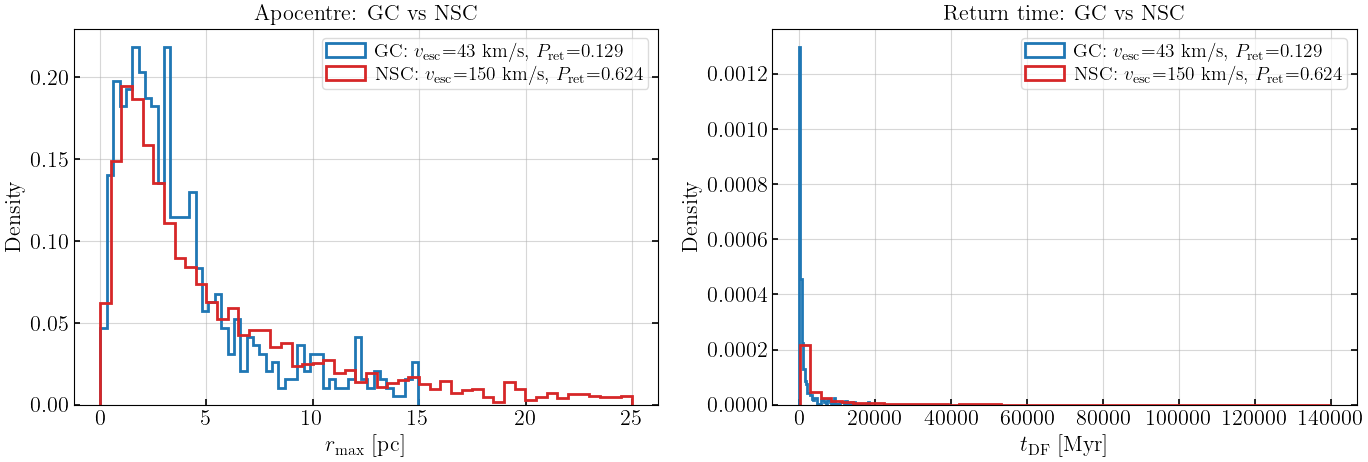

In [9]:
gc  = PlummerCluster(Mcl=5e5, r_h=3.0, cluster_type='GC')
nsc = PlummerCluster(Mcl=1e7, r_h=5.0, cluster_type='NSC')

gc.merger_analysis(v_kick, M_bh)
nsc.merger_analysis(v_kick, M_bh)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cl, label, c in [(gc, 'GC', 'C0'), (nsc, 'NSC', 'C3')]:
    if cl.retained.any():
        full_label = f'{label}: $v_{{\\rm esc}}$={cl.v_esc:.0f} km/s, $P_{{\\rm ret}}$={cl.P_ret:.3f}'
        axes[0].hist(cl.r_max[cl.retained], bins=50, density=True,
                     histtype='step', lw=2, color=c, label=full_label)
        axes[1].hist(cl.t_df[cl.retained], bins=50, density=True,
                     histtype='step', lw=2, color=c, label=full_label)

axes[0].set_xlabel(r'$r_{\rm max}$ [pc]')
axes[0].set_ylabel('Density')
axes[0].set_title('Apocentre: GC vs NSC')
axes[0].legend()

axes[1].set_xlabel(r'$t_{\rm DF}$ [Myr]')
axes[1].set_ylabel('Density')
axes[1].set_title('Return time: GC vs NSC')
axes[1].legend()

plt.tight_layout()
plt.show()

## Effect of remnant mass on return time

Heavier remnants experience stronger dynamical friction and return to the core faster.

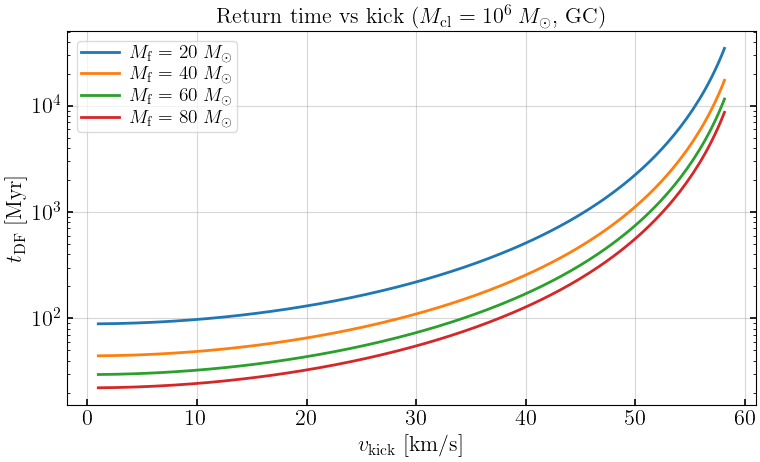

In [10]:
cl = PlummerCluster(Mcl=1e6, r_h=3.0, cluster_type='GC')

v_test = np.linspace(1, cl.v_esc * 0.95, 200)
masses = [20, 40, 60, 80]

fig, ax = plt.subplots(figsize=(8, 5))
for M in masses:
    t_df = dynamical_friction_time(v_test, cl.v_esc, cl.Mcl, cl.a, M)
    ax.semilogy(v_test, t_df, lw=2, label=rf'$M_{{\rm f}} = {M}\;M_\odot$')

ax.set_xlabel(r'$v_{\rm kick}$ [km/s]')
ax.set_ylabel(r'$t_{\rm DF}$ [Myr]')
ax.set_title(rf'Return time vs kick ($M_{{\rm cl}} = 10^6\;M_\odot$, GC)')
ax.legend()
plt.tight_layout()
plt.show()

## Standalone functions

The `plummer_apocentre` and `dynamical_friction_time` functions can be used directly without the `PlummerCluster` class.

In [11]:
v_esc = 50.0
a = 2.3
Mcl = 1e6

v_kicks = np.array([10, 20, 30, 40, 45])
r_apo = plummer_apocentre(v_kicks, v_esc, a)
t_ret = dynamical_friction_time(v_kicks, v_esc, Mcl, a, M_bh=30.0)

print(f"{'v_kick [km/s]':>14} {'r_max [pc]':>12} {'t_DF [Myr]':>12}")
print('-' * 42)
for v, r, t in zip(v_kicks, r_apo, t_ret):
    print(f"{v:14.1f} {r:12.2f} {t:12.1f}")

 v_kick [km/s]   r_max [pc]   t_DF [Myr]
------------------------------------------
          10.0         0.67         68.2
          20.0         1.49        106.6
          30.0         2.76        246.5
          40.0         5.96       1218.6
          45.0        11.88       5787.8
